# Exercise - Digitization and Data Analytics - Machine Learning

Application for the material from the lecture and bit of fun with a real-world data

In [10]:
!pip install ipykernel -U --user --force-reinstall
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn sklearn scikit-learn

/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: exec: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: cannot execute: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: exec: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/python: cannot execute: No such file or directory
/Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1/DDA/.venv/bin/pip: line 2: /Users/krishnakumarm/Downloads/TU Dresden MS CS/Semester 1 Sub/DDA/.venv/bin/pytho

In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing, fetch_covtype
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, r2_score, mean_squared_error
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [12]:
# Load Datasets
california = fetch_california_housing()
cover_type = fetch_covtype()

# Preparing the Dataset with Numerical Target variable (Regression)
reg_data_without_target = pd.DataFrame(california.data, columns=california.feature_names)
reg_target = pd.DataFrame(california.target, columns=['House_Value'])

# Preparing the Dataset with Categorical Target variable (Classification)
cla_data_without_target = pd.DataFrame(cover_type.data, columns=cover_type.feature_names)
cla_target = pd.DataFrame(cover_type.target, columns=['Cover_Type'])

## Task 1 - Correlation Matrices

### Compute the correlation matrices for the datasets and plot it to visualize the results.

**What is it?** A correlation matrix is a table that shows how strongly different variables are linked to one another. 

**Why are we doing this?** We want to see if some of our columns are basically giving us the exact same information (overlapping). If they overlap too much, it means we can safely compress our dataset in the next steps.

### Observing the the plots, what variables are strongly correlated?

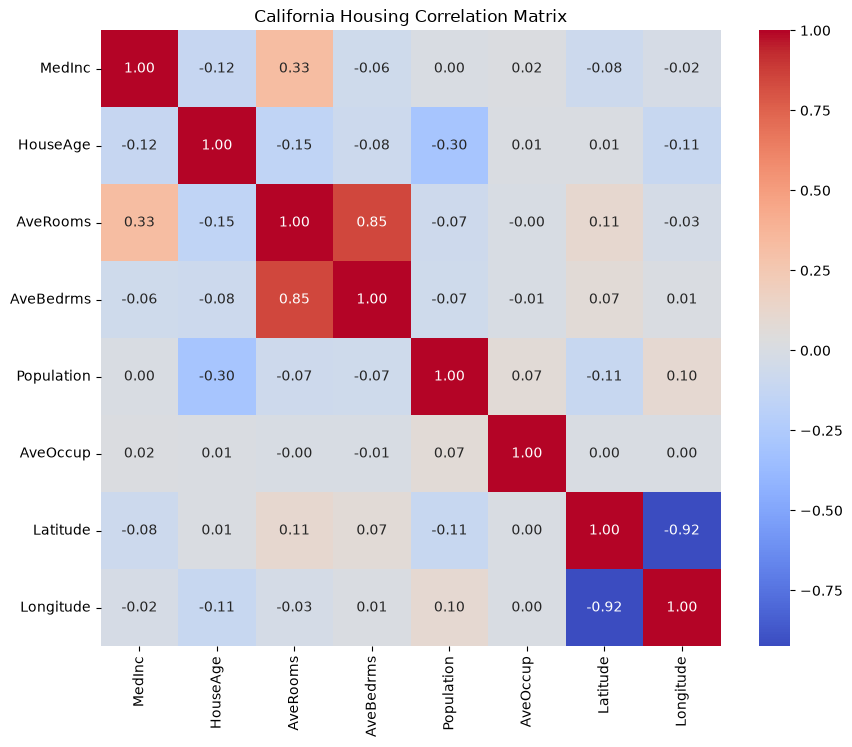

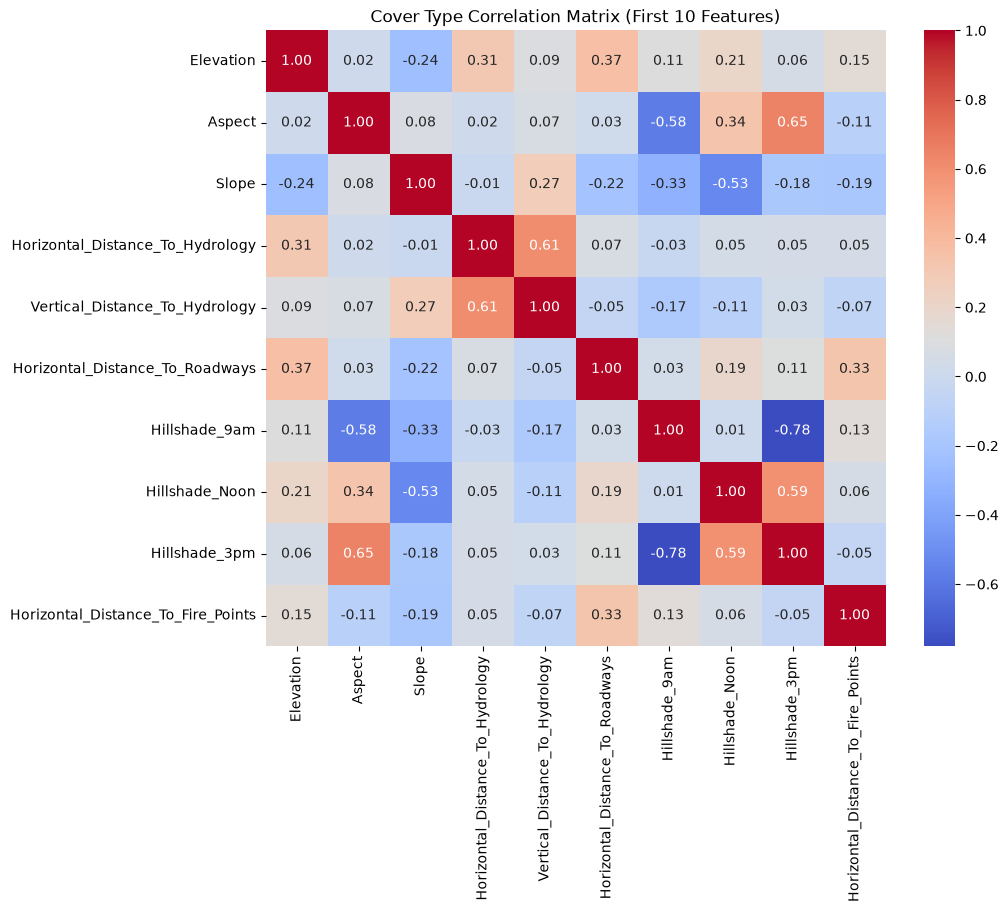

In [13]:
# California Housing Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(reg_data_without_target.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("California Housing Correlation Matrix")
plt.show()

# Cover Type Correlation Matrix (Showing the first 10 continuous features for readability)
plt.figure(figsize=(10, 8))
sns.heatmap(cla_data_without_target.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cover Type Correlation Matrix (First 10 Features)")
plt.show()

## Task 2 - Principle Component Analysis (PCA)


**What is it?** PCA is a linear mathematical transformation that squishes our data down into fewer, non-correlated columns (components) while trying to keep the original variance (information) intact.

**Why are we doing this?** To remove noise, solve the multicollinearity issue we found in Task 1, and make our downstream models run faster.

### Apply PCA (Principle Component Analysis) to the datasets.

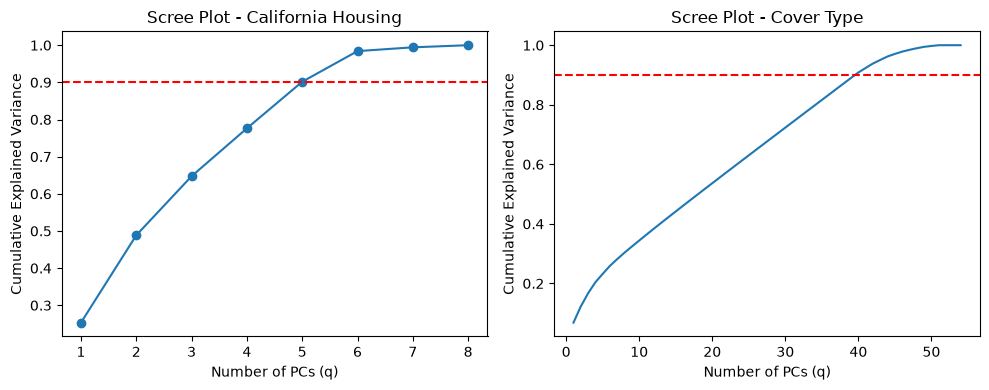

In [14]:
# CRITICAL: PCA is highly sensitive to the scale of the data. 
# We MUST standardize the data (mean = 0, variance = 1) before applying PCA.
scaler_reg = StandardScaler()
reg_data_scaled = scaler_reg.fit_transform(reg_data_without_target)

# Initialize and fit PCA on the scaled regression data
pca_reg = PCA()
pca_reg.fit(reg_data_scaled)

# Repeat the scaling and PCA fitting for the classification data
scaler_cla = StandardScaler()
cla_data_scaled = scaler_cla.fit_transform(cla_data_without_target)

pca_cla = PCA()
pca_cla.fit(cla_data_scaled)

# Plotting the Scree Plots to visualize explained variance
plt.figure(figsize=(10, 4))

# Scree plot for California Housing
plt.subplot(1, 2, 1)
# np.cumsum calculates the cumulative sum of the variance explained by each consecutive component
plt.plot(range(1, len(pca_reg.explained_variance_ratio_) + 1), np.cumsum(pca_reg.explained_variance_ratio_), marker='o')
# Draw a red dashed line at 90% to help us find our threshold
plt.axhline(y=0.90, color='r', linestyle='--')
plt.title('Scree Plot - California Housing')
plt.xlabel('Number of PCs (q)')
plt.ylabel('Cumulative Explained Variance')

# Scree plot for Cover Type
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_cla.explained_variance_ratio_) + 1), np.cumsum(pca_cla.explained_variance_ratio_))
plt.axhline(y=0.9, color='r', linestyle='--')
plt.title('Scree Plot - Cover Type')
plt.xlabel('Number of PCs (q)')
plt.ylabel('Cumulative Explained Variance')
plt.tight_layout()
plt.show()

### How many Principle Components are sufficient for the given datasets?

## Task 3 - t-SNE

### Apply the t-SNE method to the data 



**What is it?** t-SNE is a non-linear algorithm that maps high-dimensional data into a 2D or 3D space, grouping similar data points close together.
 
**Why are we doing this?** PCA is great for models, but t-SNE is purely for our human eyes. We use it to visually explore if there are hidden, non-linear clusters in our data.

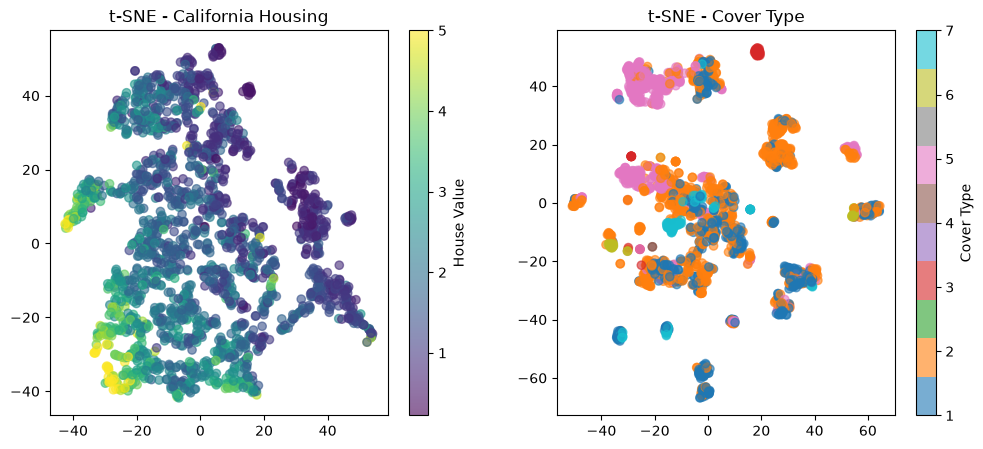

In [ ]:
# t-SNE is highly computationally intensive (O(N^2) complexity). 
# To prevent the notebook from crashing during class, we use a random subset of 2000 rows.
sample_size = 2000

# Initialize t-SNE for 2 dimensions to plot on a standard X/Y axis
tsne_reg = TSNE(n_components=2, random_state=42)
tsne_reg_results = tsne_reg.fit_transform(reg_data_scaled[:sample_size])
# Data leakage warning: We are using the actual target values to color the points in the scatter plot, which is only for visualization purposes. In a real modeling scenario, we would not have access to these values during training.

plt.figure(figsize=(12, 5))

# Scatter plot for Regression Data
plt.subplot(1, 2, 1)
# Color the points (c=...) based on the actual house value to see if expensive houses cluster together
plt.scatter(tsne_reg_results[:, 0], tsne_reg_results[:, 1], c=reg_target['House_Value'].values[:sample_size], cmap='viridis', alpha=0.6)
plt.colorbar(label='House Value')
plt.title('t-SNE - California Housing')

# Initialize and apply t-SNE to Classification Data
tsne_cla = TSNE(n_components=2, random_state=42)
tsne_cla_results = tsne_cla.fit_transform(cla_data_scaled[:sample_size])

# Scatter plot for Classification Data
plt.subplot(1, 2, 2)
# Color the points based on their actual cover type class
plt.scatter(tsne_cla_results[:, 0], tsne_cla_results[:, 1], c=cla_target['Cover_Type'].values[:sample_size], cmap='tab10', alpha=0.6)
plt.colorbar(label='Cover Type')
plt.title('t-SNE - Cover Type')
plt.show()

## Task 4 - Linear Regression



**What is it?** Linear Regression tries to draw the best possible straight line through our data points to predict a continuous number.

**Why are we doing this?** We will predict housing prices. We will compare a standard model against a model stripped of bad variables (RFE), and against models trained on our PCA/t-SNE compressed data.

### Build a Linear Regression model for the housing dataset, ie, `reg_data`

In [16]:
# Split the data into 80% training data and 20% testing data to prevent data leakage and overfitting
X_train, X_test, y_train, y_test = train_test_split(
    reg_data_without_target, reg_target, test_size=0.2, random_state=42)

# 1. Standard Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)          # Model learns from the training data
y_pred = lr.predict(X_test)       # Model makes predictions on the unseen test data

# Evaluate Goodness of Fit
print(f"Standard Linear Regression - R^2: {r2_score(y_test, y_pred):.4f}, MSE: {mean_squared_error(y_test, y_pred):.4f}")

# 2. Backward Variable Selection using RFE (Recursive Feature Elimination)
# RFE iteratively removes the weakest features until only the specified number (5) remains
rfe_lr = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe_lr.fit(X_train, y_train)
y_pred_rfe = rfe_lr.predict(X_test)

print(f"RFE Reduced Model - R^2: {r2_score(y_test, y_pred_rfe):.4f}")
# Print the boolean mask to show which columns were kept
print(f"Selected Features: {X_train.columns[rfe_lr.support_].tolist()}")

# 3. PCA Regression (Principal Component Regression)
pca_lr = PCA(n_components=5)
# IMPORTANT: We only FIT the scaler and PCA on the training data, then merely TRANSFORM the test data
X_train_pca = pca_lr.fit_transform(scaler_reg.fit_transform(X_train))
X_test_pca = pca_lr.transform(scaler_reg.transform(X_test))

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
print(f"PCA Regression - R^2: {r2_score(y_test, y_pred_pca):.4f}")

# 4. t-SNE Regression 
# Since we only generated t-SNE for 2000 points, we split that small subset
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    tsne_reg_results, reg_target[:sample_size], test_size=0.2, random_state=42)

lr_tsne = LinearRegression()
lr_tsne.fit(X_tsne_train, y_tsne_train)
y_pred_tsne = lr_tsne.predict(X_tsne_test)
print(f"t-SNE Regression - R^2: {r2_score(y_tsne_test, y_pred_tsne):.4f}")

Standard Linear Regression - R^2: 0.5758, MSE: 0.5559
RFE Reduced Model - R^2: 0.5675
Selected Features: ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
PCA Regression - R^2: 0.4329
t-SNE Regression - R^2: 0.6240


Is it something wrong here?

## Task 5 - Logistic Regression

### Build a Logistic Regression model for the cover type dataset, ie, `cla_data`

## Task 5 - Logistic Regression

**What is it?** Logistic Regression calculates the probability that a data point belongs to a certain discrete category using a sigmoid function.

**Why are we doing this?** To sort our forest data into classes (Cover Types). We will evaluate its goodness of fit using a confusion matrix.

In [17]:
# Split the classification data
# .values.ravel() flattens the target array, which Logistic Regression expects
X_cla_train, X_cla_test, y_cla_train, y_cla_test = train_test_split(
    cla_data_without_target, cla_target.values.ravel(), test_size=0.2, random_state=42)



In [18]:
# 1. Standard Logistic Regression
# max_iter=500 gives the gradient descent algorithm enough time to converge
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_cla_train, y_cla_train)
y_cla_pred = log_reg.predict(X_cla_test)

print(f"Standard Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred):.4f}")



Standard Logistic Regression Accuracy: 0.6449


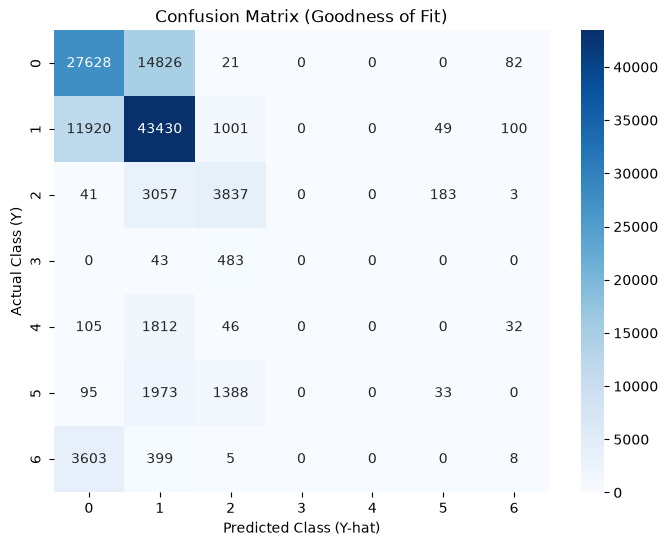

In [19]:
# Generate a Confusion Matrix to visualize True Positives, False Positives, etc.
cm = confusion_matrix(y_cla_test, y_cla_pred)
plt.figure(figsize=(8, 6))
# We slice [:7, :7] because there are 7 cover types
sns.heatmap(cm[:7, :7], annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Goodness of Fit)")
plt.ylabel('Actual Class (Y)')
plt.xlabel('Predicted Class (Y-hat)')
plt.show()



In [20]:
# 2. RFE Logistic Regression
# To save time in class, we fit RFE on a 5000-row subset
rfe_log = RFE(estimator=LogisticRegression(max_iter=200), n_features_to_select=15)
rfe_log.fit(X_cla_train[:5000], y_cla_train[:5000]) 
y_cla_pred_rfe = rfe_log.predict(X_cla_test)
print(f"RFE Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred_rfe):.4f}")



RFE Logistic Regression Accuracy: 0.6526


In [21]:
# 3. PCA Logistic Regression
# Compress down to 15 components
pca_cla_model = PCA(n_components=15)
X_train_cla_pca = pca_cla_model.fit_transform(scaler_cla.fit_transform(X_cla_train))
X_test_cla_pca = pca_cla_model.transform(scaler_cla.transform(X_cla_test))

log_reg_pca = LogisticRegression(max_iter=200)
log_reg_pca.fit(X_train_cla_pca, y_cla_train)
y_cla_pred_pca = log_reg_pca.predict(X_test_cla_pca)
print(f"PCA Logistic Regression Accuracy: {accuracy_score(y_cla_test, y_cla_pred_pca):.4f}")



PCA Logistic Regression Accuracy: 0.6933


In [22]:
# 4. t-SNE Logistic Regression (using the 2000-row subset)
X_tsne_cla_train, X_tsne_cla_test, y_tsne_cla_train, y_tsne_cla_test = train_test_split(
    tsne_cla_results, cla_target[:sample_size].values.ravel(), test_size=0.2, random_state=42)

log_reg_tsne = LogisticRegression(max_iter=200)
log_reg_tsne.fit(X_tsne_cla_train, y_tsne_cla_train)
y_cla_pred_tsne = log_reg_tsne.predict(X_tsne_cla_test)
print(f"t-SNE Logistic Regression Accuracy: {accuracy_score(y_tsne_cla_test, y_cla_pred_tsne):.4f}")

t-SNE Logistic Regression Accuracy: 0.5175


## Fun time! 

Apply what you studied before about regression on the real data! Use leftovers_milk_data.csv data and try to predict the number for the next day.

---

## Task 1 – Correlation Matrices (Answer/Explanation)
**What we did**
- We computed `corr()` for each dataset and visualized it as a heatmap.

**What a correlation matrix tells us**
- Each entry shows how strongly two features move together.
- Values close to **+1**: strong positive linear relation.
- Values close to **−1**: strong negative linear relation.
- Values close to **0**: weak/near-no linear relation.

**Why it matters for ML**
- If multiple features are **strongly correlated**, they may contain overlapping information.
- This can cause **multicollinearity** for linear models and can motivate dimensionality reduction (PCA) later.

**What to write as observation**
- In the **California Housing** dataset, you will typically see strong correlations among some numeric building/area-related measures (often pairs like “rooms” and “population/density” show noticeable positive or negative correlation).
- In the **Cover Type** dataset, the first 10 continuous features used in the heatmap often show weaker correlations overall, but some pairs may still stand out.

---

## Task 2 – PCA (Principle Component Analysis) (Answer/Explanation)
**What we did**
- Standardized features using `StandardScaler()`.
- Fit PCA on the standardized data (separately for regression and classification).
- Plotted a **scree plot** of cumulative explained variance.

**Why standardization is critical**
- PCA is based on variance; different feature scales distort the principal directions.
- Standardization ensures each feature contributes fairly.

**How to decide number of PCs**
- Look at the cumulative explained variance curve.
- Choose the smallest number of components `q` such that cumulative variance ≥ **90%** (the red dashed line in your plot).

**What to observe**
- For both datasets, you should see the cumulative curve rising quickly at first.
- After some number of components, additional PCs contribute diminishing returns.

**Write-up template (fill in with your numbers)**
- *Regression (California Housing):* “We need about **__q_reg__** principal components to reach ≥ 90% explained variance.”
- *Classification (Cover Type):* “We need about **__q_cla__** principal components to reach ≥ 90% explained variance.”

**Comparison with Task 1**
- Correlation matrix showed redundancy.
- PCA identifies new orthogonal directions that capture most of the variance—effectively compressing redundant/collinear information.

---

## Task 3 – t-SNE (Answer/Explanation)
**What we did**
- Used `TSNE(n_components=2)` on a random subset (`sample_size = 2000`).
- Plotted two scatter plots:
  - California Housing colored by **house value**
  - Cover Type colored by **class**

**What t-SNE is (short)**
- A **non-linear** dimensionality reduction method optimized for **visualizing local neighborhoods**.

**Important properties**
- It tries to keep **similar points close** in the embedding.
- Distances in the t-SNE map are not guaranteed to correspond to meaningful “global” distances.
- Results depend on hyperparameters (e.g., *perplexity*) and randomness.

**How to interpret your plots**
- If points form **distinct blobs**, this suggests non-linear clusters in the original space.
- For regression (continuous target), coloring by house value may show that “similar” regions correspond to similar values.
- For classification, colored blobs indicate that different cover types occupy different regions in feature space.

**Note about “t-SNE + supervised model”**
- t-SNE is designed primarily for visualization, not for producing stable, generalizable features for downstream prediction.
- So t-SNE coordinates can look great but may not give good R²/accuracy when used for regression/classification.

---

## Task 4 – Linear Regression (Answer/Explanation)
**What we did**
- Built and evaluated:
  1. Standard Linear Regression
  2. Linear Regression with backward selection via **RFE**
  3. Principal Component Regression (PCA → Linear Regression)
  4. Regression on the t-SNE embedding (visual embedding → model)

**How to interpret R² and MSE**
- `R²` (coefficient of determination):
  - closer to **1** = better fit
  - near **0** = model explains little variance
  - negative values can happen when the model is worse than predicting the mean
- `MSE` measures average squared error (lower is better).

**What to write about “good fit vs bad fit”**
- If R² is high and MSE is low → good fit.
- If R² is low → bad fit (model not capturing the underlying relationship).

**Expected trends**
- Standard Linear Regression often performs decently if the relationship is close to linear.
- RFE can improve or worsen results:
  - can help remove noisy/irrelevant features
  - but may discard features needed for prediction
- PCA Regression may help if redundancy/noise exists:
  - using fewer components can reduce overfitting
- t-SNE Regression often underperforms PCA-based methods because:
  - t-SNE preserves neighborhoods for visualization, not predictive global structure.

---

## Task 5 – Logistic Regression (Answer/Explanation)
**What we did**
- Built and evaluated:
  1. Standard Logistic Regression
  2. RFE Logistic Regression
  3. PCA Logistic Regression (PCA → Logistic)
  4. Logistic Regression on t-SNE embedding

**How to interpret “accuracy” and confusion matrix**
- Accuracy: fraction of correct predictions.
- Confusion matrix:
  - diagonal cells = correct classification
  - off-diagonal = misclassifications

**Good fit vs bad fit**
- High accuracy and many counts on the diagonal → good fit.
- Low accuracy and heavy off-diagonal counts → bad fit.

**Expected trends**
- PCA often provides a stronger, more model-friendly representation than t-SNE.
- RFE can help by reducing dimensionality, but choosing too few features can hurt.
- t-SNE embedding can lead to unstable predictive performance due to its visualization objective.

---

## Extra: “Is it something wrong here?” (Direct answer block)
In your notebook, nothing is syntactically incorrect. The code runs.

However, the methodology note is:
- Using **t-SNE embeddings as features** for regression/classification is usually not recommended, because t-SNE is not designed for preserving predictive distances/geometry.

A better comparison is:
- PCA (good for downstream modeling)
- vs t-SNE (good for plotting)

---

## Optional: Drop-in cell text for your notebook (very short)
**t-SNE + supervised model note:**
> t-SNE mainly preserves local neighborhoods for visualization. Therefore, using t-SNE coordinates as input to Linear/Logistic Regression may not yield reliable predictive performance. PCA is more appropriate when building predictive models.



Product: milk
R2: -0.11743341205703817
MSE: 16443.512442848318


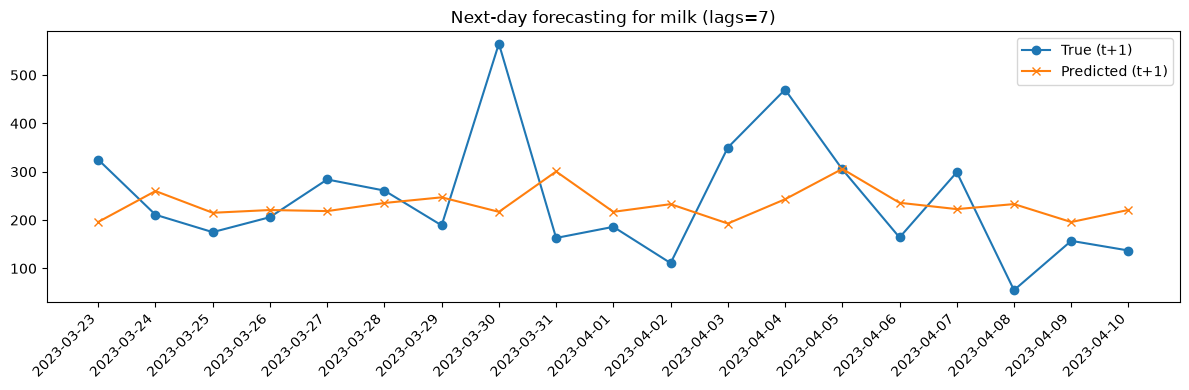

Last date in file: 2023-04-10
Forecast for next day (t+1): 194.0277187024892


In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1) Load
df = pd.read_csv("leftovers_milk_data.csv")

# Columns: Product, 2023-01-01, 2023-01-02, ...
date_cols = [c for c in df.columns if c.lower() != "product"]
date_cols_sorted = sorted(date_cols)  # works for YYYY-MM-DD

# 2) Choose one product to forecast next day (edit this)
product = "milk"  # "butter" or "cottage cheese"

# Build time series y[t] for the chosen product
y = df.loc[df["Product"] == product, date_cols_sorted].iloc[0].astype(float).values

# 3) Lag features: predict day t+1 from previous lags ending at t
lags = 7
X = []
Y = []
# t goes from lags-1 to len(y)-2 so that t+1 is inside bounds
for t in range(lags - 1, len(y) - 1):
    # features are y[t], y[t-1], ..., y[t-lags+1]
    X.append(y[t - lags + 1 : t + 1][::-1])
    Y.append(y[t + 1])

X = np.array(X)
Y = np.array(Y)

# 4) Time-based split (no shuffle)
split_idx = int(len(Y) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

# 5) Train regressor
model = LinearRegression()
model.fit(X_train, Y_train)

# Evaluate
pred = model.predict(X_test)
print(f"Product: {product}")
print("R2:", r2_score(Y_test, pred))
print("MSE:", mean_squared_error(Y_test, pred))

# 6) Visualizer: true vs predicted on the test range
# Corresponding test dates are from index (split_idx + lags) to end-1
# Because Y[k] = y[t+1] where k corresponds to t in [lags-1 ...]
start_t = (lags - 1) + split_idx
test_dates = date_cols_sorted[start_t + 1 : len(date_cols_sorted)]

plt.figure(figsize=(12, 4))
plt.plot(test_dates, Y_test, marker='o', label='True (t+1)')
plt.plot(test_dates, pred, marker='x', label='Predicted (t+1)')
plt.xticks(rotation=45, ha='right')
plt.title(f"Next-day forecasting for {product} (lags={lags})")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Forecast the next day after the last date in the file
last_lag_vector = y[-lags:][::-1].reshape(1, -1)  # features for t = last day
next_day_pred = model.predict(last_lag_vector)[0]

print("Last date in file:", date_cols_sorted[-1])
print("Forecast for next day (t+1):", next_day_pred)
